Классификация. Алгоритм Дерево решений

In [2]:
# Установка зависимостей
import sys
import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

## Исходные данные

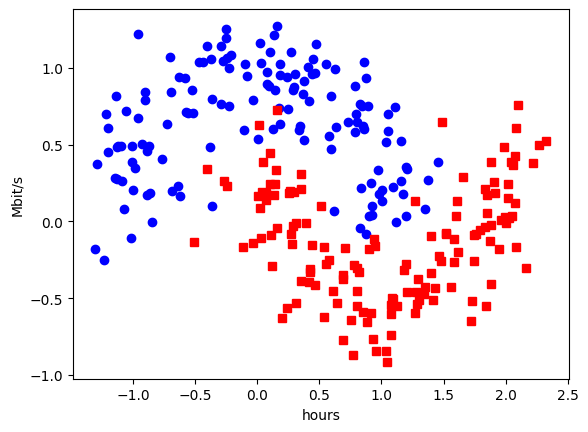

In [3]:
X, y = make_moons(n_samples=400, noise=0.2, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

plt.plot(X_train[y_train==0,0], X_train[y_train==0,1],'ob')
plt.plot(X_train[y_train==1,0], X_train[y_train==1,1],'sr')
plt.xlabel("hours")
plt.ylabel("Mbit/s")
plt.show()

### Реализация алгоритма вручную

tree created
{'feature': 0, 'threshold': np.float64(-0.5682568344145388), 'left': 0}
{'feature': 0, 'threshold': np.float64(-0.43756399502392607), 'left': 1}
{'feature': 0, 'threshold': np.float64(-0.43756399502392607), 'left': 1, 'right': 0}
{'feature': 0, 'threshold': np.float64(-0.2589325368626587), 'left': 1}
{'feature': 0, 'threshold': np.float64(-0.1796326303063671), 'left': 1}
{'feature': 0, 'threshold': np.float64(-0.07276388704904352), 'left': 1}
{'feature': 0, 'threshold': np.float64(-0.012250179824181022), 'left': 1}
{'feature': 0, 'threshold': np.float64(0.016519303129892117), 'left': 1}
{'feature': 0, 'threshold': np.float64(0.02931727360268705), 'left': 1}
{'feature': 0, 'threshold': np.float64(0.03745350663971469), 'left': 1}
{'feature': 0, 'threshold': np.float64(0.05726304056712369), 'left': 1}
{'feature': 0, 'threshold': np.float64(0.07318370105030969), 'left': 1}
{'feature': 0, 'threshold': np.float64(0.08611977459361028), 'left': 1}
{'feature': 0, 'threshold': np.fl

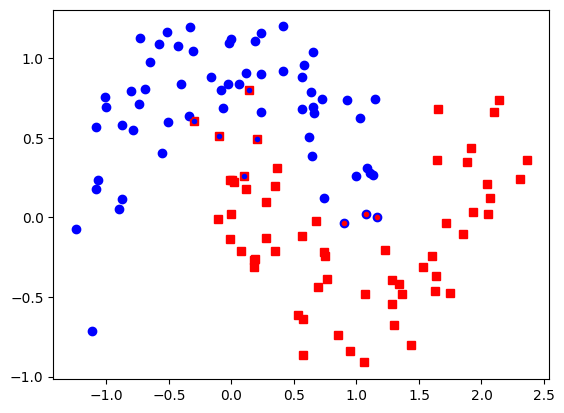

0.0


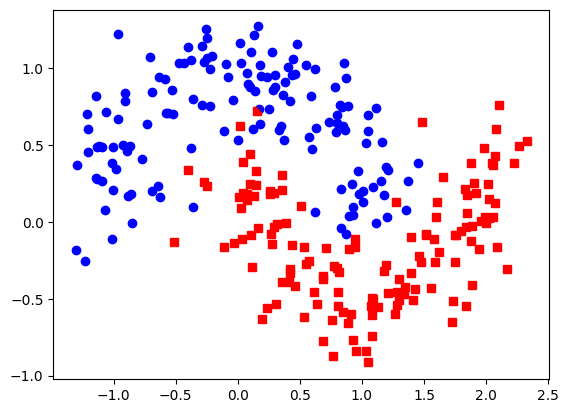

In [9]:
class DecisionTree():
  def __init__(self,n_intervals=10):
    self.n_intervals=n_intervals
    self.node = {}
    self.eps = sys.float_info.epsilon
    print("tree created")

  def train(self,X,y):
    """Построить дерево по обучающей выборке X, y"""
    self._split(X,y, self.node)

  def predict(self,X):
    """Вернуть массив предсказаний для объектов X"""
    y_pred = np.ones(X.shape[0])
    for i in range(X.shape[0]):
      y_pred[i] = self.check_split(X[i,:],self.node)

    return y_pred

  def _split(self, X, y, node):
    """Рекурсивное построение дерева: выбор лучшего сплита и создание поддеревьев"""
    feature, threshold, error = self._find_best_split(X, y)

    # если ни одного годного порога не нашлось (все пороги дают ошибку 1.0)
    if error == 1.0:
      self._make_leaf(node, y)
      return

    node['feature'] = feature
    node['threshold'] = threshold

    X_left, y_left, X_right, y_right = self._split_node(X, y, feature, threshold)

    # если одна из сторон пустая
    if len(y_left) == 0 or len(y_right) == 0:
      self._make_leaf(node, y)
      return

    self._build_subtree(node, 'left',  X_left,  y_left)
    self._build_subtree(node, 'right', X_right, y_right)

  def _find_best_split(self, X, y):
    """Поиск лучшего признака и порога по критерию минимальной ошибки классификации"""
    error = 1.0
    y_pred = np.zeros(len(y), dtype=int)
    threshold = 0.0
    feature = 0

    for i in range(X.shape[1]):  # feature
      vals = np.unique(X[:, i])
      if len(vals) < 2:
        continue
      thresholds = (vals[:-1] + vals[1:]) / 2.
      for j in thresholds:       # threshold
        for k in range(len(y)):  # data
          y_pred[k] = 0 if X[k, i] < j else 1

        tmp_error = (y != y_pred).sum() / len(y)
        tmp_error = min(tmp_error, 1 - tmp_error)

        if tmp_error < error - self.eps:
          error = tmp_error
          threshold = j
          feature  = i

    return feature, threshold, error

  def _make_leaf(self, node, y):
    """Преобразовать узел в лист с меткой по большинству"""
    node.clear()
    majority = self._majority(y)
    node['left'] = node['right'] = majority
    node['feature'] = None
    node['threshold'] = None

  def _split_node(self, X, y, feature, threshold):
    """Разделить данные на левую и правую подвыборки"""
    left_mask = X[:, feature] < threshold
    right_mask = X[:, feature] >= threshold
    return X[left_mask, :], y[left_mask], X[right_mask, :], y[right_mask]

  def _build_subtree(self, node, branch, X_child, y_child):
    """Построить поддерево для одной из ветвей (left/right)"""
    if self._is_terminal(y_child):
        node[branch] = int(y_child[0])
        print(node)
    else:
        node[branch] = {}
        self._split(X_child, y_child, node[branch])

  def _is_terminal(self, y):
    """Проверка на то что все ли объекты в подвыборке принадлежат одному классу"""
    return y.min() == y.max()

  def _majority(self, y):
    """Определить класс большинства (0 или 1)"""
    return 1 if np.sum(y) >= len(y)/2 else 0

  def check_split(self, x, node):
    """Обход дерева для одного объекта x до достижения листа"""
    # если узел — лист, то возвращаем значение
    if 'feature' not in node or node['feature'] is None:
      return node['left'] if 'left' in node else node.get('value', 0)

    if x[node['feature']] < node['threshold']: # x[feature] < threshold
      # left
      if node['left'] in (0,1):
        return node['left']
      else:
        return self.check_split(x, node['left'])
    else:
      # right
      if node['right'] in (0,1):
        return node['right']
      else:
        return self.check_split(x, node['right'])


tree = DecisionTree()
tree.train(X_train,y_train)

y_pred = tree.predict(X_test)

print((y_test != y_pred).sum() / len(y_test))

plt.plot(X_test[y_test==0,0], X_test[y_test==0,1],'ob')
plt.plot(X_test[y_test==1,0], X_test[y_test==1,1],'sr')
plt.plot(X_test[y_pred==0,0], X_test[y_pred==0,1],'.b')
plt.plot(X_test[y_pred==1,0], X_test[y_pred==1,1],'.r')

plt.show()
y_pred = tree.predict(X_train)
print((y_train != y_pred).sum() / len(y_train))

plt.plot(X_train[y_train==0,0], X_train[y_train==0,1],'ob')
plt.plot(X_train[y_train==1,0], X_train[y_train==1,1],'sr')
plt.plot(X_train[y_pred==0,0], X_train[y_pred==0,1],'.b')
plt.plot(X_train[y_pred==1,0], X_train[y_pred==1,1],'.r')
plt.show()

### Применяем алгоритм, используя фреймворк

In [ ]:
# Параметры
criterion = "gini" # 'gini', 'entropy', 'log_loss' | default='gini'
splitter = "best" # 'best' или 'random' | default='best'
max_depth = None # int или None | default=None
min_samples_split = 2 # int или float | default=2
min_samples_leaf = 1 # int или float | default=1
max_features = None # int, float, 'sqrt', 'log2' или None | default=None

Accuracy: 0.942
F1 Score: 0.940


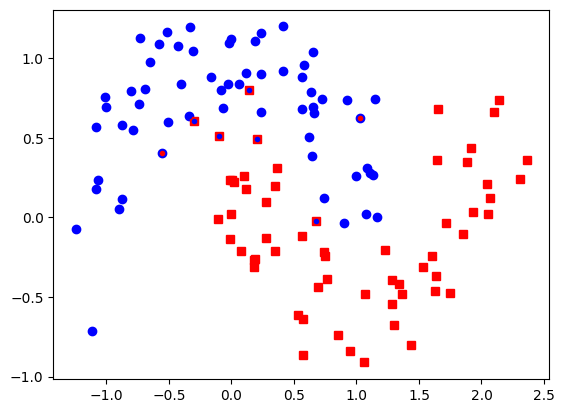

In [ ]:
clf = DecisionTreeClassifier(
    criterion=criterion,
    splitter=splitter,
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf,
    max_features=max_features
)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Accuracy: {acc:.3f}")
print(f"F1 Score: {f1:.3f}")

plt.plot(X_test[y_test==0,0], X_test[y_test==0,1], 'ob')
plt.plot(X_test[y_test==1,0], X_test[y_test==1,1], 'sr')
plt.plot(X_test[y_pred==0,0], X_test[y_pred==0,1], '.b')
plt.plot(X_test[y_pred==1,0], X_test[y_pred==1,1], '.r')
plt.show()

In [ ]:
# Кроссвалидация
cv = 10
print(cross_val_score(clf, X, y, cv=cv)) # scoring=None
print(cross_val_score(clf, X, y, cv=cv, scoring='accuracy'))
print(cross_val_score(clf, X, y, cv=cv, scoring='f1'))

[0.925 0.975 0.9   1.    0.975 0.9   0.925 0.9   0.925 0.925]
[0.925 0.975 0.9   1.    0.975 0.9   0.925 0.925 0.925 0.925]
[0.92682927 0.97435897 0.9        0.97560976 0.97435897 0.9
 0.92682927 0.91891892 0.95       0.92682927]
